In [1]:
!apt-get install graphviz
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-9ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [2]:
import os
import time
import graphviz
from google.colab import drive

drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/Trabalho_Arvores/Patricia'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Pasta de destino pronta em: {OUTPUT_DIR}")

Mounted at /content/drive
Pasta de destino pronta em: /content/drive/MyDrive/Trabalho_Arvores/Patricia


In [3]:
class PatriciaNode:
    def __init__(self, prefix: str = ""):
        self.prefix = prefix
        self.children = {}
        self.is_end_of_word = False

class PatriciaInstrumentada:
    def __init__(self):
        self.root = PatriciaNode()
        self.comparisons_count = 0
        self.splits_count = 0
        self.merges_count = 0
        self.nodes_count = 1

    def reset_metrics(self):
        self.comparisons_count = 0
        self.splits_count = 0
        self.merges_count = 0

    def insert(self, word: str) -> None:
        curr = self.root
        i = 0
        while i < len(word):
            char = word[i]
            self.comparisons_count += 1
            if char not in curr.children:
                new_node = PatriciaNode(word[i:])
                new_node.is_end_of_word = True
                curr.children[char] = new_node
                self.nodes_count += 1
                return

            child = curr.children[char]
            child_prefix = child.prefix
            j = 0
            while j < len(child_prefix) and (i + j) < len(word) and child_prefix[j] == word[i + j]:
                self.comparisons_count += 1
                j += 1

            if j < len(child_prefix):
                self.splits_count += 1
                split_node = PatriciaNode(child_prefix[:j])
                split_node.children[child_prefix[j]] = child
                child.prefix = child_prefix[j:]
                curr.children[char] = split_node
                self.nodes_count += 1

                if i + j == len(word):
                    split_node.is_end_of_word = True
                else:
                    new_node = PatriciaNode(word[i + j:])
                    new_node.is_end_of_word = True
                    split_node.children[word[i + j]] = new_node
                    self.nodes_count += 1
                return
            else:
                i += j
                curr = child

        curr.is_end_of_word = True

    def search(self, word: str) -> bool:
        curr = self.root
        i = 0
        while i < len(word):
            char = word[i]
            self.comparisons_count += 1
            if char not in curr.children:
                return False
            child = curr.children[char]
            child_prefix = child.prefix
            if not word.startswith(child_prefix, i):
                return False
            i += len(child_prefix)
            curr = child
        return curr.is_end_of_word

    def delete(self, word: str) -> bool:
        def _delete(curr, word, i):
            if i == len(word):
                if not curr.is_end_of_word:
                    return False
                curr.is_end_of_word = False
                return True

            char = word[i]
            self.comparisons_count += 1
            if char not in curr.children:
                return False

            child = curr.children[char]
            if not word.startswith(child.prefix, i):
                return False

            deleted = _delete(child, word, i + len(child.prefix))

            if deleted:
                if len(child.children) == 0 and not child.is_end_of_word:
                    del curr.children[char]
                    self.nodes_count -= 1
                elif len(child.children) == 1 and not child.is_end_of_word:
                    self.merges_count += 1
                    only_key, only_child = next(iter(child.children.items()))
                    child.prefix += only_child.prefix
                    child.is_end_of_word = only_child.is_end_of_word
                    child.children = only_child.children
                    self.nodes_count -= 1

            return deleted

        return _delete(self.root, word, 0)

    def save_diagram(self, filename: str, directory: str = OUTPUT_DIR):
        dot = graphviz.Digraph(comment='Patricia Tree')

        def _add_nodes(node, parent_id="root"):
            for first_char, child in node.children.items():
                child_id = str(id(child))
                label = f'"{child.prefix}"' + (" (*)" if child.is_end_of_word else "")
                color = "blue" if child.is_end_of_word else "black"
                dot.node(child_id, label=label, color=color)
                dot.edge(parent_id, child_id, label=first_char)
                _add_nodes(child, child_id)

        dot.node("root", "ROOT", shape="box")
        _add_nodes(self.root)

        filepath = dot.render(filename=filename, directory=directory, format='png', cleanup=True)
        print(f"Diagrama Patricia salvo em: {filepath}")
        return dot

Diagrama Patricia salvo em: /content/drive/MyDrive/Trabalho_Arvores/Patricia/patricia_teste.png


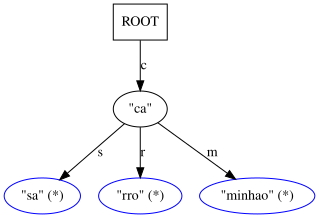

In [4]:
patricia = PatriciaInstrumentada()
patricia.insert("casa")
patricia.insert("carro")
patricia.insert("caminhao")

dot_patricia = patricia.save_diagram("patricia_teste", directory=OUTPUT_DIR)
display(dot_patricia)